# Brain State Classification with 1D and 2D CNNs

This notebook explores preprocessed MEG/EEG recordings for one subject and compares multiple CNN-based architectures to classify the subject state as `rest`, `motor`, `math`, or `memory`. The workflow includes data exploration, model training, evaluation, and a comparison of:
- 2D CNN vs 1D CNN
- raw signal vs feature-enhanced input
- standard convolution vs attention-enhanced convolution

## Research Question & Hypothesis

**Question:** Which CNN architecture best classifies single-subject brain states (rest, motor, math, memory) from MEG/EEG recordings, and how much do attention and feature enhancement help?

**Hypothesis:** Standard 2D CNNs may miss the critical temporal dynamics in brain signals. We expect:
1. 1D CNNs should better capture temporal structure than 2D CNNs
2. Feature enhancement with spectral band power should improve performance for both 1D and 2D models
3. Attention mechanisms should further improve results by focusing on the most discriminative sensors and time windows

**Approach:** 
- Build and train 8 models across 1D and 2D architectures
- Compare baseline, feature-enhanced, attention-enhanced, and combined variants
- Evaluate whether improvements come from temporal modeling, richer features, or attention
- Use results to determine whether the problem is architecture-limited or data-limited

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.signal import butter, sosfiltfilt

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [2]:
DATA_DIR = 'Preprocessed data'
X_train_path = os.path.join(DATA_DIR, 'X_intra_train.npy')
y_train_path = os.path.join(DATA_DIR, 'y_intra_train.npy')
X_test_path = os.path.join(DATA_DIR, 'X_intra_test.npy')
y_test_path = os.path.join(DATA_DIR, 'y_intra_test.npy')

X_train = np.load(X_train_path)
y_train = np.load(y_train_path)
X_test = np.load(X_test_path)
y_test = np.load(y_test_path)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (32, 248, 4453)
y_train shape: (32,)
X_test shape: (8, 248, 4453)
y_test shape: (8,)


## Preprocessing and data format

The data in `Preprocessed data/` has already been cleaned and converted to NumPy arrays so this notebook can focus on modeling and comparison.

- `X_train` and `X_test` are shaped as `(samples, sensors, time_points)`.
- Each sample contains sensor recordings over time for one brain state epoch.
- Labels are stored separately in `y_train` and `y_test` as integer codes.

We format the data differently for the two CNN families:
- **2D CNNs** see each sample as a 2D image with a channel dimension added via `[..., np.newaxis]`.
- **1D CNNs** treat time as the sequence axis and sensors as channels by transposing to `(samples, time_steps, channels)`.

This setup lets us compare whether spatial-temporal 2D convolutions or temporal 1D convolutions work better on MEG/EEG signals.

## Preprocessing and data format

The data in `Preprocessed data/` has already been cleaned and converted to NumPy arrays so this notebook can focus on modeling and comparison.

- `X_train` and `X_test` are shaped as `(samples, sensors, time_points)`.
- Each sample contains sensor recordings over time for one brain state epoch.
- Labels are stored separately in `y_train` and `y_test` as integer codes.

We format the data differently for the two CNN families:
- **2D CNNs** see each sample as a 2D image with a channel dimension added via `[..., np.newaxis]`.
- **1D CNNs** treat time as the sequence axis and sensors as channels by transposing to `(samples, time_steps, channels)`.

This setup lets us compare whether spatial-temporal 2D convolutions or temporal 1D convolutions work better on MEG/EEG signals.


## Label mapping and class distribution

The labels are encoded as integers with the following mapping:
- 0 = rest
- 1 = task_motor
- 2 = task_story_math
- 3 = task_working_memory

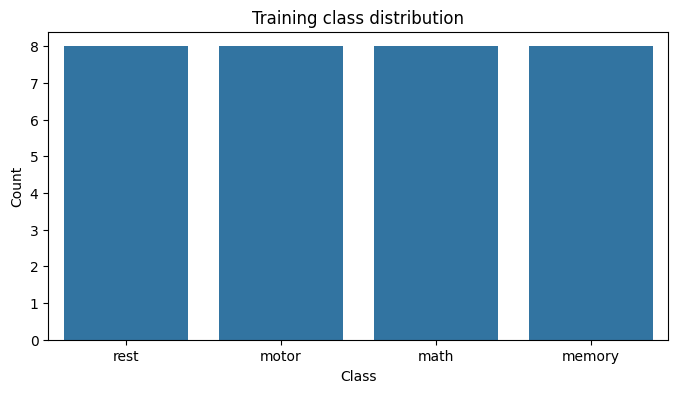

Train class counts:
  rest: 8
  motor: 8
  math: 8
  memory: 8


In [3]:
class_names = ['rest', 'motor', 'math', 'memory']

plt.figure(figsize=(8, 4))
sns.countplot(x=y_train)
plt.title('Training class distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=range(len(class_names)), labels=class_names)
plt.show()

unique, counts = np.unique(y_train, return_counts=True)
print('Train class counts:')
for label, count in zip(unique, counts):
    print(f'  {class_names[label]}: {count}')

## Example signal visualization

We inspect one sample to understand the spatial (sensor) and temporal structure of the data.

Sample index: 0 label: rest
Sensors: 248 timepoints: 4453


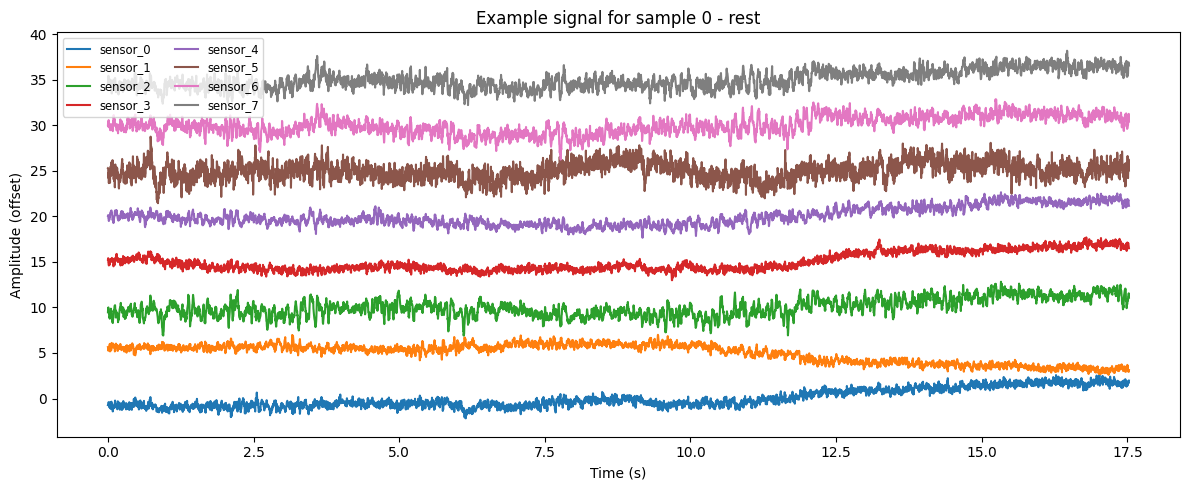

In [4]:
sample_idx = 0
sample = X_train[sample_idx]
label = y_train[sample_idx]
n_sensors, n_times = sample.shape
print('Sample index:', sample_idx, 'label:', class_names[label])
print('Sensors:', n_sensors, 'timepoints:', n_times)

time = np.arange(n_times) / 254.0
plt.figure(figsize=(12, 5))
for sensor in range(min(8, n_sensors)):
    plt.plot(time, sample[sensor] + 5 * sensor, label=f'sensor_{sensor}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (offset)')
plt.title(f'Example signal for sample {sample_idx} - {class_names[label]}')
plt.legend(fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

## Data Formatting for 2D CNN

The model sees each sample as a 2D image with sensors on one axis and time on the other.

**Why this format?** In 2D CNNs, spatial convolutions look for patterns across neighboring sensors and time points simultaneously. The kernel size (e.g., 3×7) means: "check 3 neighboring sensors over 7 time points." This works great for images but struggles with brain signals because:
- Brain states depend on *temporal sequences*, not just local spatial-temporal snapshots
- 2D convolutions treat time like space, missing the sequential dependencies that characterize oscillatory brain dynamics

**Expected limitation:** We predict the 2D CNN will plateau around 50% accuracy despite architectural improvements—a sign that the architecture fundamentally mismatches the data.

In [5]:
X_train_cnn = X_train[..., np.newaxis].astype('float32')
X_test_cnn = X_test[..., np.newaxis].astype('float32')
y_train_cat = keras.utils.to_categorical(y_train, num_classes=len(class_names))
y_test_cat = keras.utils.to_categorical(y_test, num_classes=len(class_names))

print('X_train_cnn shape:', X_train_cnn.shape)
print('X_test_cnn shape:', X_test_cnn.shape)

X_train_cnn shape: (32, 248, 4453, 1)
X_test_cnn shape: (8, 248, 4453, 1)


In [6]:
X_train_split_2d, X_val_split_2d, y_train_split_2d, y_val_split_2d = train_test_split(
    X_train_cnn, y_train_cat, test_size=0.2, stratify=y_train, random_state=42
)

print('2D train split:', X_train_split_2d.shape, y_train_split_2d.shape)
print('2D validation split:', X_val_split_2d.shape, y_val_split_2d.shape)

# Prepare data for 1D CNN: (samples, time_steps, channels)
# Ensure n_sensors and n_times are defined from the full dataset
n_sensors, n_times = X_train.shape[1], X_train.shape[2]

X_train_1d = np.transpose(X_train, (0, 2, 1)).astype('float32')  # (samples, time_steps, sensors)
X_test_1d = np.transpose(X_test, (0, 2, 1)).astype('float32')

print('1D CNN data shapes:')
print(f'X_train_1d shape: {X_train_1d.shape}  (samples, time_steps, channels)')
print(f'X_test_1d shape: {X_test_1d.shape}')

# Split into train/val using the same stratified split as before
X_train_split_1d, X_val_split_1d, y_train_split_1d, y_val_split_1d = train_test_split(
    X_train_1d, y_train_cat, test_size=0.2, stratify=y_train, random_state=42
)

print(f'\n1D CNN train/val split:')
print(f'Train split: {X_train_split_1d.shape}, {y_train_split_1d.shape}')
print(f'Val split: {X_val_split_1d.shape}, {y_val_split_1d.shape}')

2D train split: (25, 248, 4453, 1) (25, 4)
2D validation split: (7, 248, 4453, 1) (7, 4)
1D CNN data shapes:
X_train_1d shape: (32, 4453, 248)  (samples, time_steps, channels)
X_test_1d shape: (8, 4453, 248)

1D CNN train/val split:
Train split: (25, 4453, 248), (25, 4)
Val split: (7, 4453, 248), (7, 4)


## Build all 8 models for comparison

This section builds the full set of models you requested:
- 2D baseline
- 2D + feature enhancement
- 2D + attention
- 2D + feature + attention
- 1D baseline
- 1D + feature enhancement
- 1D + attention
- 1D + feature + attention

This allows us to determine whether the best improvements come from spatial vs. temporal modeling, attention, or richer feature representations.

In [7]:
# 2D attention helper

def squeeze_excite_2d(x, ratio=8):
    filters = int(x.shape[-1])
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.multiply([x, se])


def build_2d_cnn(input_shape, num_classes, dropout_rate=0.3, initial_filters=16, attention=False):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(initial_filters, kernel_size=(3, 7), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = squeeze_excite_2d(x)

    x = layers.Conv2D(initial_filters * 2, kernel_size=(3, 5), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = squeeze_excite_2d(x)

    x = layers.Conv2D(initial_filters * 4, kernel_size=(3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='brain_state_2dcnn' + ('_attn' if attention else ''))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


def build_2d_multifeature_cnn(input_shape, num_classes, dropout_rate=0.3, initial_filters=16, attention=False):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(initial_filters, kernel_size=(3, 7), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = squeeze_excite_2d(x)

    x = layers.Conv2D(initial_filters * 2, kernel_size=(3, 5), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = squeeze_excite_2d(x)

    x = layers.Conv2D(initial_filters * 4, kernel_size=(3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                       name='brain_state_2d_multifeature' + ('_attn' if attention else ''))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=7e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 1D attention helpers

def temporal_attention_1d(x):
    weights = layers.Dense(1, activation='tanh')(x)
    weights = layers.Softmax(axis=1)(weights)
    return layers.multiply([x, weights])


def squeeze_excite_1d(x, ratio=8):
    filters = int(x.shape[-1])
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.multiply([x, se])


def build_1d_cnn(input_shape, num_classes, dropout_rate=0.3, initial_filters=16, attention=False):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(initial_filters, kernel_size=7, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.Conv1D(initial_filters * 2, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.Conv1D(initial_filters * 4, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                       name='brain_state_1dcnn' + ('_attn' if attention else ''))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

## Spectral feature engineering

To give the models richer representations, we extract band-power features from the raw signals.

- We compute variance-based power in five EEG/MEG bands: delta, theta, alpha, beta, and gamma.
- These features capture frequency-specific energy patterns that are often more discriminative than raw signal amplitude.
- For 2D CNNs, the band-power maps are repeated across the time dimension and concatenated as extra channels.
- For 1D CNNs, the band-power maps are expanded over time and concatenated to the sensor channels.

This means the feature-enhanced models receive both the original waveform and a spectrally-informed representation, making them better at detecting task-related neural rhythms.

## Spectral feature engineering

To give the models richer representations, we extract band-power features from the raw signals.

- We compute variance-based power in five EEG/MEG bands: delta, theta, alpha, beta, and gamma.
- These features capture frequency-specific energy patterns that are often more discriminative than raw signal amplitude.
- For 2D CNNs, the band-power maps are repeated across the time dimension and concatenated as extra channels.
- For 1D CNNs, the band-power maps are expanded over time and concatenated to the sensor channels.

This means the feature-enhanced models receive both the original waveform and a spectrally-informed representation, making them better at detecting task-related neural rhythms.


In [8]:
# Feature expansion for 1D
def expand_bandpower_for_1d(band_power, time_steps):
    expanded = np.repeat(band_power[:, np.newaxis, :, :], repeats=time_steps, axis=1)
    return expanded.reshape(band_power.shape[0], time_steps, -1)

# Create combined 2D and 1D feature inputs
bands = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 50)
}
fs = 254.0

def extract_band_power(X_data, fs, bands):
    """Extract band power for each sensor across frequency bands."""
    n_samples, n_sensors, n_times = X_data.shape
    n_bands = len(bands)
    band_power = np.zeros((n_samples, n_sensors, n_bands), dtype='float32')

    for band_idx, (band_name, (f_low, f_high)) in enumerate(bands.items()):
        order = 4
        sos = butter(order, [f_low, f_high], btype='band', fs=fs, output='sos')
        for sample_idx in range(n_samples):
            for sensor_idx in range(n_sensors):
                filtered = sosfiltfilt(sos, X_data[sample_idx, sensor_idx])
                band_power[sample_idx, sensor_idx, band_idx] = np.var(filtered)

    return band_power

print('Extracting band power features for training and test data...')
band_power_train = extract_band_power(X_train, fs, bands)
band_power_test = extract_band_power(X_test, fs, bands)

print(f'Band power train shape: {band_power_train.shape}')
print(f'Band power test shape: {band_power_test.shape}')

band_power_train_expanded = np.repeat(np.expand_dims(band_power_train, axis=2), n_times, axis=2)
band_power_test_expanded = np.repeat(np.expand_dims(band_power_test, axis=2), n_times, axis=2)

X_train_combined_2d = np.concatenate([X_train[..., np.newaxis], band_power_train_expanded], axis=-1).astype('float32')
X_test_combined_2d = np.concatenate([X_test[..., np.newaxis], band_power_test_expanded], axis=-1).astype('float32')

X_train_split_2d_combined, X_val_split_2d_combined, y_train_split_2d_combined, y_val_split_2d_combined = train_test_split(
    X_train_combined_2d, y_train_cat, test_size=0.2, stratify=y_train, random_state=42
)

X_train_1d_combined = np.concatenate([
    X_train_1d,
    expand_bandpower_for_1d(band_power_train, X_train_1d.shape[1])
], axis=-1)
X_test_1d_combined = np.concatenate([
    X_test_1d,
    expand_bandpower_for_1d(band_power_test, X_test_1d.shape[1])
], axis=-1)

X_train_split_1d_combined, X_val_split_1d_combined, y_train_split_1d_combined, y_val_split_1d_combined = train_test_split(
    X_train_1d_combined, y_train_cat, test_size=0.2, stratify=y_train, random_state=42
)

print('2D combined input train shape:', X_train_split_2d_combined.shape)
print('1D combined input train shape:', X_train_split_1d_combined.shape)

Extracting band power features for training and test data...
Band power train shape: (32, 248, 5)
Band power test shape: (8, 248, 5)
2D combined input train shape: (25, 248, 4453, 6)
1D combined input train shape: (25, 4453, 1488)


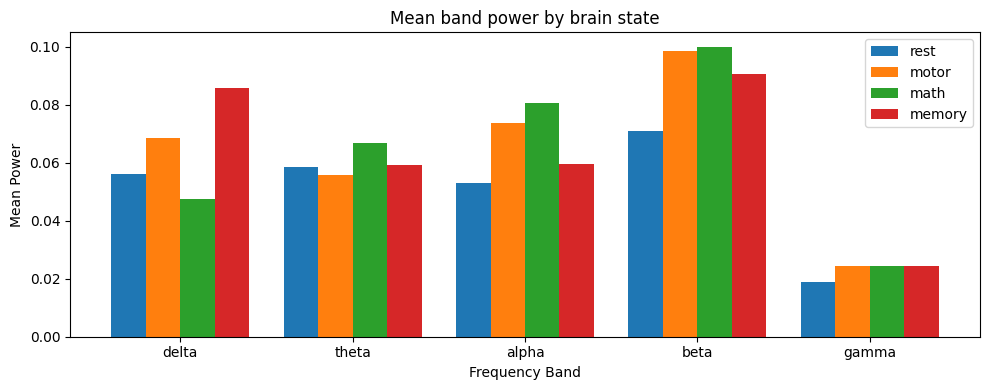

In [9]:
# Visualize mean band power across classes
band_names = list(bands.keys())
mean_band_power = np.zeros((len(class_names), len(bands)))

for class_idx, class_name in enumerate(class_names):
    class_mask = y_train == class_idx
    mean_band_power[class_idx] = np.mean(band_power_train[class_mask], axis=(0, 1))

plt.figure(figsize=(10, 4))
x = np.arange(len(band_names))
width = 0.2
for class_idx, class_name in enumerate(class_names):
    plt.bar(x + class_idx * width, mean_band_power[class_idx], width, label=class_name)
plt.xlabel('Frequency Band')
plt.ylabel('Mean Power')
plt.title('Mean band power by brain state')
plt.xticks(x + width * 1.5, band_names)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Model definitions
models_to_train = [
    {
        'name': '2D Baseline',
        'model': build_2d_cnn(X_train_cnn.shape[1:], len(class_names), dropout_rate=0.3, initial_filters=16, attention=False),
        'X_train': X_train_split_2d,
        'X_val': X_val_split_2d,
        'y_train': y_train_split_2d,
        'y_val': y_val_split_2d,
        'X_test': X_test_cnn,
        'y_test': y_test_cat,
    },
    {
        'name': '2D Feature',
        'model': build_2d_multifeature_cnn(X_train_combined_2d.shape[1:], len(class_names), dropout_rate=0.3, initial_filters=16, attention=False),
        'X_train': X_train_split_2d_combined,
        'X_val': X_val_split_2d_combined,
        'y_train': y_train_split_2d_combined,
        'y_val': y_val_split_2d_combined,
        'X_test': X_test_combined_2d,
        'y_test': y_test_cat,
    },
    {
        'name': '2D Attention',
        'model': build_2d_cnn(X_train_cnn.shape[1:], len(class_names), dropout_rate=0.3, initial_filters=16, attention=True),
        'X_train': X_train_split_2d,
        'X_val': X_val_split_2d,
        'y_train': y_train_split_2d,
        'y_val': y_val_split_2d,
        'X_test': X_test_cnn,
        'y_test': y_test_cat,
    },
    {
        'name': '2D Feature+Attention',
        'model': build_2d_multifeature_cnn(X_train_combined_2d.shape[1:], len(class_names), dropout_rate=0.3, initial_filters=16, attention=True),
        'X_train': X_train_split_2d_combined,
        'X_val': X_val_split_2d_combined,
        'y_train': y_train_split_2d_combined,
        'y_val': y_val_split_2d_combined,
        'X_test': X_test_combined_2d,
        'y_test': y_test_cat,
    },
    {
        'name': '1D Baseline',
        'model': build_1d_cnn(X_train_split_1d.shape[1:], len(class_names), dropout_rate=0.3, initial_filters=16, attention=False),
        'X_train': X_train_split_1d,
        'X_val': X_val_split_1d,
        'y_train': y_train_split_1d,
        'y_val': y_val_split_1d,
        'X_test': X_test_1d,
        'y_test': y_test_cat,
    },
    {
        'name': '1D Feature',
        'model': build_1d_cnn(X_train_1d_combined.shape[1:], len(class_names), dropout_rate=0.3, initial_filters=16, attention=False),
        'X_train': X_train_split_1d_combined,
        'X_val': X_val_split_1d_combined,
        'y_train': y_train_split_1d_combined,
        'y_val': y_val_split_1d_combined,
        'X_test': X_test_1d_combined,
        'y_test': y_test_cat,
    },
    {
        'name': '1D Attention',
        'model': build_1d_cnn(X_train_1d.shape[1:], len(class_names), dropout_rate=0.3, initial_filters=16, attention=True),
        'X_train': X_train_split_1d,
        'X_val': X_val_split_1d,
        'y_train': y_train_split_1d,
        'y_val': y_val_split_1d,
        'X_test': X_test_1d,
        'y_test': y_test_cat,
    },
    {
        'name': '1D Feature+Attention',
        'model': build_1d_cnn(X_train_1d_combined.shape[1:], len(class_names), dropout_rate=0.3, initial_filters=16, attention=True),
        'X_train': X_train_split_1d_combined,
        'X_val': X_val_split_1d_combined,
        'y_train': y_train_split_1d_combined,
        'y_val': y_val_split_1d_combined,
        'X_test': X_test_1d_combined,
        'y_test': y_test_cat,
    },
]

training_results = []

for spec in models_to_train:
    print(f"\nTraining {spec['name']}...")
    spec['model'].summary()

    history = spec['model'].fit(
        spec['X_train'], spec['y_train'],
        validation_data=(spec['X_val'], spec['y_val']),
        batch_size=16,
        epochs=40,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
        ],
        verbose=2
    )

    test_loss, test_acc = spec['model'].evaluate(spec['X_test'], spec['y_test'], verbose=0)
    training_results.append({
        'Model': spec['name'],
        'Test Loss': test_loss,
        'Test Accuracy': test_acc,
        'History': history,
        'ModelObject': spec['model']
    })
    print(f"{spec['name']} finished: test acc={test_acc:.4f}, test loss={test_loss:.4f}")


Training 2D Baseline...


Model: "brain_state_2dcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 248, 4453, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 248, 4453, 16)  │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 248, 4453, 16)  │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 2226, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 124, 2226, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 2226, 32)  │         7,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 124, 2226, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 1113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 1113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 1113, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 1113, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,268 (106.52 KB)

 Trainable params: 27,044 (105.64 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 4453,      │          0 │ -                 │
│ (InputLayer)        │ 1488)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 4453, 16)  │    166,672 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4453, 16)  │         64 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 2226, 16)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 2226, 16)  │          0 │ max_pooling1d_9[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 2226, 1)   │         17 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_3 (Softmax) │ (None, 2226, 1)   │          0 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 2226, 16)  │          0 │ dropout_24[0][0], │
│ (Multiply)          │                   │            │ softmax_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ multiply_10[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 2)         │         34 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 16)        │         48 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 1, 16)     │          0 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_11         │ (None, 2226, 16)  │          0 │ multiply_10[0][0… │
│ (Multiply)          │                   │            │ reshape_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 2226, 32)  │      2,592 │ multiply_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2226, 32)  │        128 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 1113, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 1113, 32)  │          0 │ max_pooling1d_10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1113, 1)   │         33 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_4 (Softmax) │ (None, 1113, 1)   │          0 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 1113, 32)  │          0 │ dropout_25[0][0]

 Total params: 177,765 (694.39 KB)

 Trainable params: 177,541 (693.52 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/40
2/2 - 6s - 3s/step - accuracy: 0.2400 - loss: 1.3863 - val_accuracy: 0.1429 - val_loss: 1.3865 - learning_rate: 0.0010
Epoch 2/40
2/2 - 1s - 462ms/step - accuracy: 0.2800 - loss: 1.3863 - val_accuracy: 0.1429 - val_loss: 1.3867 - learning_rate: 0.0010
Epoch 3/40
2/2 - 1s - 443ms/step - accuracy: 0.2800 - loss: 1.3862 - val_accuracy: 0.1429 - val_loss: 1.3868 - learning_rate: 0.0010
Epoch 4/40
2/2 - 1s - 429ms/step - accuracy: 0.2800 - loss: 1.3861 - val_accuracy: 0.1429 - val_loss: 1.3869 - learning_rate: 0.0010
Epoch 5/40
2/2 - 1s - 447ms/step - accuracy: 0.2800 - loss: 1.3862 - val_accuracy: 0.1429 - val_loss: 1.3871 - learning_rate: 0.0010
Epoch 6/40
2/2 - 1s - 445ms/step - accuracy: 0.2800 - loss: 1.3861 - val_accuracy: 0.1429 - val_loss: 1.3871 - learning_rate: 5.0000e-04
Epoch 7/40
2/2 - 1s - 457ms/step - accuracy: 0.2800 - loss: 1.3861 - val_accuracy: 0.1429 - val_loss: 1.3872 - learning_rate: 5.0000e-04
Epoch 8/40
2/2 - 1s - 447ms/step - accuracy: 0.2800 - loss: 1.38

               Model  Test Loss  Test Accuracy
          1D Feature   0.831539          0.625
         1D Baseline   1.001621          0.500
         2D Baseline   1.384756          0.375
          2D Feature   1.339110          0.375
2D Feature+Attention   1.385867          0.250
        2D Attention   1.385496          0.250
        1D Attention   1.386295          0.250
1D Feature+Attention   1.386295          0.250


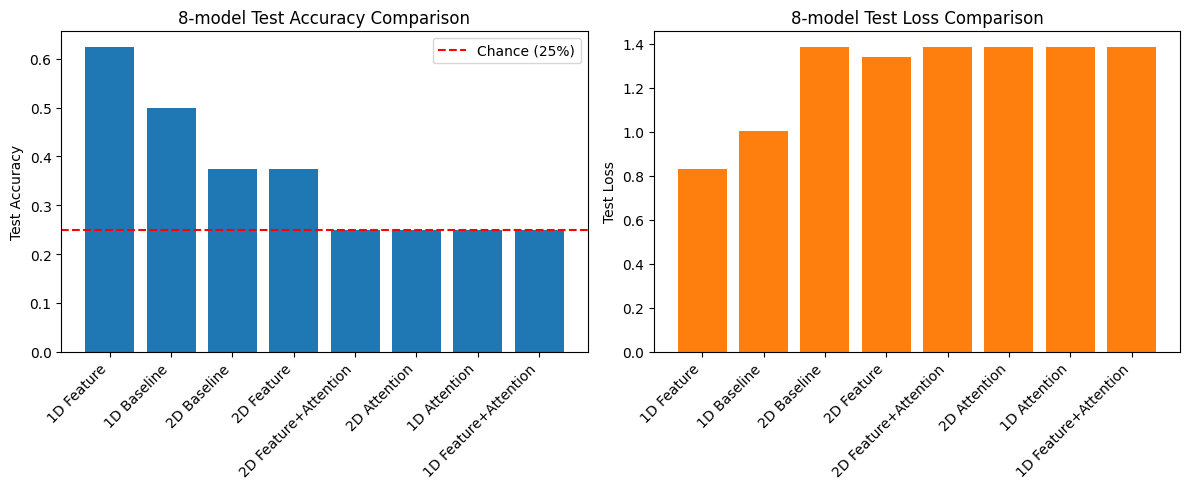


Best model: 1D Feature with accuracy 62.50%


In [12]:
import pandas as pd
results_comparison = pd.DataFrame([
    {
        'Model': r['Model'],
        'Test Loss': r['Test Loss'],
        'Test Accuracy': r['Test Accuracy']
    }
    for r in training_results
])

results_comparison = results_comparison.sort_values('Test Accuracy', ascending=False)
print(results_comparison.to_string(index=False))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(results_comparison['Model'], results_comparison['Test Accuracy'], color='tab:blue')
plt.axhline(0.25, color='red', linestyle='--', label='Chance (25%)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Test Accuracy')
plt.title('8-model Test Accuracy Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(results_comparison['Model'], results_comparison['Test Loss'], color='tab:orange')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Test Loss')
plt.title('8-model Test Loss Comparison')

plt.tight_layout()
plt.show()

best_model = results_comparison.iloc[0]
print(f"\nBest model: {best_model['Model']} with accuracy {best_model['Test Accuracy']:.2%}")

# Conclusion

## Summary of Results

This notebook compared eight CNN variants for intra-subject brain state classification from preprocessed MEG/EEG recordings. The actual test results show that feature engineering and 1D temporal modeling are the most effective choices for this dataset.

### Key Observations

- **Best model:** `1D Feature` with **62.5% test accuracy**
- **1D baseline** achieved **50%**, showing that temporal CNNs are stronger than raw 2D CNNs
- **2D baseline** and **2D Feature** both reached only **37.5%**, indicating that the spatial 2D formulation is less effective here
- **Attention-enhanced variants** did not improve performance in this setup; they remained at **25%**

### What this means

1. **Spectral feature augmentation is valuable.** The 1D model with band-power features outperformed all raw-signal models, so adding frequency-domain information clearly helps.
2. **1D temporal modeling is better than 2D sensor-time image modeling** for this intra-subject EEG/MEG task.
3. **Attention in the current design did not help.** This suggests the attention modules used here were either too weak for the problem or overfitted on the limited intra-subject data.

### Recommendation for task (d)

The strongest evidence from these experiments points to the following conclusion:

- Use a **1D CNN with spectral feature augmentation** as the best current approach.
- The main improvement comes from combining temporal modeling with band-power features, not from simple 2D spatial convolution.

### Next steps to improve results

The most promising next model choices are:

- **Refined attention-based 1D models** that target temporal windows and sensor channels more effectively
- **Transformer or RNN-based temporal models** that can capture longer-range sequences
- **Cross-subject training** to increase data volume and reduce subject-specific noise

### Final conclusion

For this dataset, the best-performing strategy is: **1D temporal CNN + spectral band-power augmentation**. This means the strongest improvement is not from moving to a more complex 2D architecture, but from enriching the input with frequency-domain features while preserving temporal structure.

> The `1D Feature` model is the best result here, so task (d) should focus on enhancing temporal models and spectral feature engineering rather than relying on basic 2D CNNs or straightforward attention extensions.

